In [1]:
import pandas as pd
import matplotlib.pyplot as plt
movies = pd.read_csv('dataset/movies.csv')
ratings = pd.read_csv('dataset/ratings.csv')
tags = pd.read_csv('dataset/tags.csv')
CURRENT_USER = 64

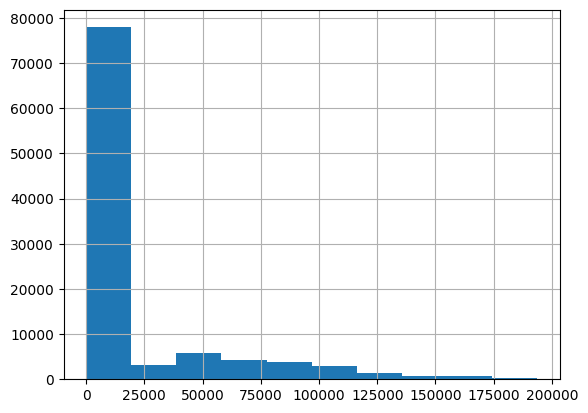

In [2]:
ratings['movieId'].hist()
plt.show()

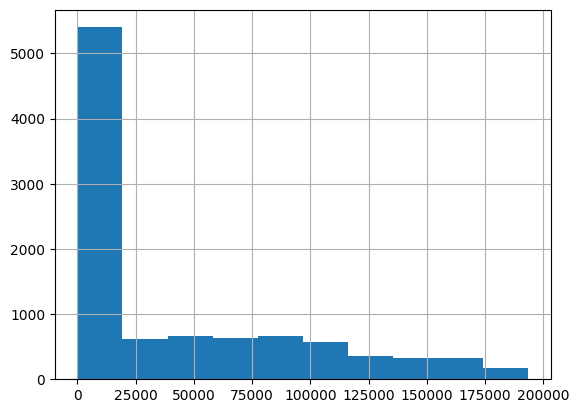

In [3]:
movies['movieId'].hist()
plt.show()

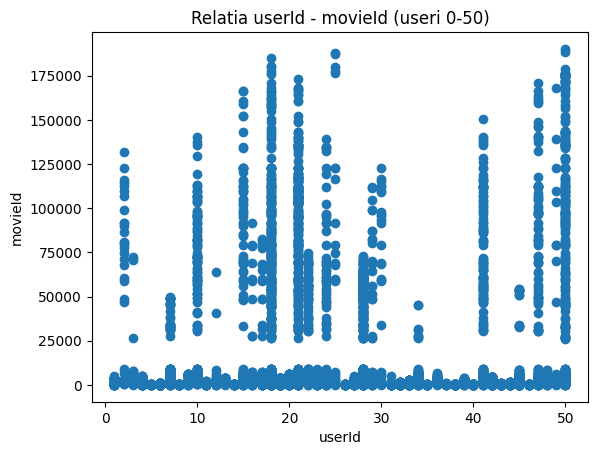

In [4]:
# relatie intre userId si movieId (doar userii 0-50)
subset = ratings[ratings['userId'] <= 50]
plt.scatter(subset['userId'], subset['movieId'])
plt.xlabel('userId')
plt.ylabel('movieId')
plt.title('Relatia userId - movieId (useri 0-50)')
plt.show()

In [5]:
# Tratarea valorilor lipsa
# nr filme care in entitate genres au valoarea "no genres listed"
print((movies['genres'] == '(no genres listed)').sum())
# inlocuim valoarea "no genres listed" cu un string gol
movies['genres'] = movies['genres'].replace('(no genres listed)', '')

34


In [6]:
movies['genres_list'] = movies['genres'].apply(
    lambda x: x.split('|') if x != '' else []
)

# Extragere an din titlu
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

movies.head(5)

,movieId,title,genres,genres_list,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0
1,2,Jumanji,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",1995.0
2,3,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",1995.0
3,4,Waiting to Exhale,Comedy|Drama|Romance,"[Comedy, Drama, Romance]",1995.0
4,5,Father of the Bride Part II,Comedy,[Comedy],1995.0


In [7]:
#completarea manuala a anului pentru filmele fara an
year_map = {
    40697: 1993, 140956: 2018, 143410: 2015, 147250: 1980,
    149334: 2016, 156605: 2016, 162414: 2016, 167570: 2016,
    171495: 2019, 171631: 2017, 171749: 2006, 171891: 2017,
    176601: 2011
}
movies['year'] = movies['year'].fillna(movies['movieId'].map(year_map))

In [8]:
print("Analiza movies:")
display(movies.shape)
display(movies.head())
display(movies.info())
display(movies.describe())
display(movies.isnull().sum())
display(movies['year'].isnull().sum())

Analiza movies:


(9742, 5)

,movieId,title,genres,genres_list,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0
1,2,Jumanji,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",1995.0
2,3,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",1995.0
3,4,Waiting to Exhale,Comedy|Drama|Romance,"[Comedy, Drama, Romance]",1995.0
4,5,Father of the Bride Part II,Comedy,[Comedy],1995.0


<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   movieId      9742 non-null   int64  
 1   title        9742 non-null   str    
 2   genres       9742 non-null   str    
 3   genres_list  9742 non-null   object 
 4   year         9742 non-null   float64
dtypes: float64(1), int64(1), object(1), str(2)
memory usage: 380.7+ KB


None

,movieId,year
count,9742.000000,9742.000000
mean,42200.353623,1994.635188
std,52160.494854,18.536694
min,1.000000,1902.000000
25%,3248.250000,1988.000000
50%,7300.000000,1999.000000
75%,76232.000000,2008.000000
max,193609.000000,2019.000000


movieId        0
title          0
genres         0
genres_list    0
year           0
dtype: int64

np.int64(0)

In [9]:
#Ratings : conversie timestamp -> datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
print("Ratings - timestamp to datetime")
display(ratings[['userId', 'movieId', 'rating', 'timestamp']].head())

Ratings - timestamp to datetime


,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [10]:
print("\nAnaliza ratings:")
display(ratings.shape)
display(ratings.head())
display(ratings.info())
display(ratings.describe())
display(ratings.isnull().sum())


Analiza ratings:


(100836, 4)

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype        
---  ------     --------------   -----        
 0   userId     100836 non-null  int64        
 1   movieId    100836 non-null  int64        
 2   rating     100836 non-null  float64      
 3   timestamp  100836 non-null  datetime64[s]
dtypes: datetime64[s](1), float64(1), int64(2)
memory usage: 3.1 MB


None

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,100836
mean,326.127564,19435.295718,3.501557,2008-03-19 17:01:27
min,1.000000,1.000000,0.500000,1996-03-29 18:36:55
25%,177.000000,1199.000000,3.000000,2002-04-18 09:57:46
50%,325.000000,2991.000000,3.500000,2007-08-02 20:31:02
75%,477.000000,8122.000000,4.000000,2015-07-04 07:15:44
max,610.000000,193609.000000,5.000000,2018-09-24 14:27:30
std,182.618491,35530.987199,1.042529,NaN


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [11]:
# normalizare tag-uri(lowercase, whitespaces)
print("Exemple inainte de normalizare:")
display(tags['tag'].head(10))

tags['tag'] = tags['tag'].astype(str).str.lower().str.strip()

print("\nExemple dupa normalizare:")
display(tags['tag'].head(10))

Exemple inainte de normalizare:


0                funny
1      Highly quotable
2         will ferrell
3         Boxing story
4                  MMA
5            Tom Hardy
6                drugs
7    Leonardo DiCaprio
8      Martin Scorsese
9         way too long
Name: tag, dtype: str


Exemple dupa normalizare:


0                funny
1      highly quotable
2         will ferrell
3         boxing story
4                  mma
5            tom hardy
6                drugs
7    leonardo dicaprio
8      martin scorsese
9         way too long
Name: tag, dtype: str

In [12]:
# Tags : conversie timestamp -> datetime
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

print("\nTags - timestamp to datetime")
display(tags[['userId', 'movieId', 'tag', 'timestamp']].head())


Tags - timestamp to datetime


,userId,movieId,tag,timestamp
0,2,60756,funny,2015-10-24 19:29:54
1,2,60756,highly quotable,2015-10-24 19:29:56
2,2,60756,will ferrell,2015-10-24 19:29:52
3,2,89774,boxing story,2015-10-24 19:33:27
4,2,89774,mma,2015-10-24 19:33:20


In [13]:
print("\nAnaliza tags:")
display(tags.shape)
display(tags.head())
display(tags.info())
display(tags.describe())
display(tags.isnull().sum())
display(tags.duplicated().sum())


Analiza tags:


(3683, 4)

,userId,movieId,tag,timestamp
0,2,60756,funny,2015-10-24 19:29:54
1,2,60756,highly quotable,2015-10-24 19:29:56
2,2,60756,will ferrell,2015-10-24 19:29:52
3,2,89774,boxing story,2015-10-24 19:33:27
4,2,89774,mma,2015-10-24 19:33:20


<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   userId     3683 non-null   int64        
 1   movieId    3683 non-null   int64        
 2   tag        3683 non-null   str          
 3   timestamp  3683 non-null   datetime64[s]
dtypes: datetime64[s](1), int64(2), str(1)
memory usage: 115.2 KB


None

,userId,movieId,timestamp
count,3683.000000,3683.000000,3683
mean,431.149335,27252.013576,2011-10-31 03:32:46
min,2.000000,1.000000,2006-01-13 19:09:12
25%,424.000000,1262.500000,2006-01-17 18:06:56
50%,474.000000,4454.000000,2010-03-29 03:16:04
75%,477.000000,39263.000000,2017-06-26 05:59:25
max,610.000000,193565.000000,2018-09-16 11:50:03
std,158.472553,43490.558803,NaN


userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

np.int64(0)

In [14]:
# Cati utilizatori unici
display(ratings['userId'].nunique())
# Cate filme unice au primit rating
display(ratings['movieId'].nunique())
# Distributia rating-urilor
display(ratings['rating'].describe())
display(ratings['rating'].value_counts().sort_index())
# Cate rating-uri a dat fiecare utilizator
display(ratings.groupby('userId')['rating'].count().describe())
# Cate rating-uri are fiecare film
display(ratings.groupby('movieId')['rating'].count().describe())

610

9724

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64

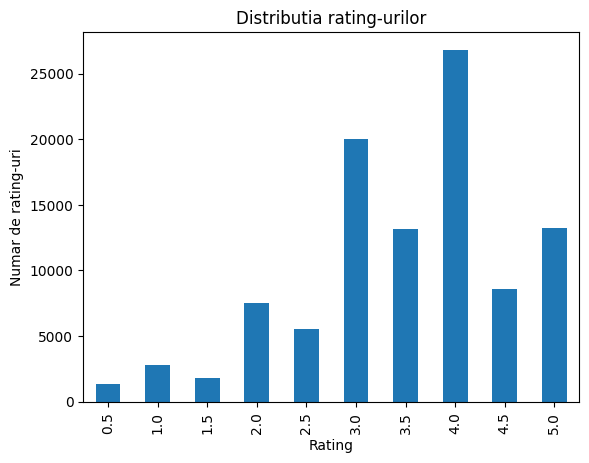

In [15]:
# Distributia rating-urilor (grafic)
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Rating')
plt.ylabel('Numar de rating-uri')
plt.title('Distributia rating-urilor')
plt.show()

In [16]:
# numarul valorilor lipsa
display(movies.isnull().sum())
display(ratings.isnull().sum())
display(tags.isnull().sum())

# numarul duplicatelor
display(movies.drop(columns=['genres_list']).duplicated().sum())
display(ratings.duplicated().sum())
display(tags.duplicated().sum())

movieId        0
title          0
genres         0
genres_list    0
year           0
dtype: int64

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

np.int64(0)

np.int64(0)

np.int64(0)

In [17]:

# FEATURE ENGINEERING

In [18]:
# Features per film
movie_stats = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

display(movie_stats.round(2).head(10))
display(movie_stats.describe())

# Ma ajuta strict sa vad cat de bun este un film bazat pe rating-urile
# oferite de useri. Daca un film are media rating-ului de 4.5 si 1000 de rating-uri, acesta pare sa fie un film foarte bun.

,movieId,avg_rating,num_ratings
0,1,3.92,215
1,2,3.43,110
2,3,3.26,52
3,4,2.36,7
4,5,3.07,49
5,6,3.95,102
6,7,3.19,54
7,8,2.88,8
8,9,3.12,16
9,10,3.50,132


,movieId,avg_rating,num_ratings
count,9724.000000,9724.000000,9724.000000
mean,42245.024373,3.262448,10.369807
std,52191.137320,0.869874,22.401005
min,1.000000,0.500000,1.000000
25%,3245.500000,2.800000,1.000000
50%,7300.000000,3.416667,3.000000
75%,76739.250000,3.911765,9.000000
max,193609.000000,5.000000,329.000000


In [19]:
# Features per user
user_stats = ratings.groupby('userId').agg(
    user_avg_rating=('rating', 'mean'),
    user_num_ratings=('rating', 'count')
).reset_index()

display(user_stats.round(2).head(10))
display(user_stats.describe())

# ajuta modelul sa inteleaga "presonalitatea" fiecarui user.
# Daca de exemplu user-ul 1 a avut media rating-ului de 4.37 si 232 rating-uri,
# acesta pare sa fie mai generos

,userId,user_avg_rating,user_num_ratings
0,1,4.37,232
1,2,3.95,29
2,3,2.44,39
3,4,3.56,216
4,5,3.64,44
5,6,3.49,314
6,7,3.23,152
7,8,3.57,47
8,9,3.26,46
9,10,3.28,140


,userId,user_avg_rating,user_num_ratings
count,610.000000,610.000000,610.000000
mean,305.500000,3.657222,165.304918
std,176.236111,0.480635,269.480584
min,1.000000,1.275000,20.000000
25%,153.250000,3.360000,35.000000
50%,305.500000,3.694385,70.500000
75%,457.750000,3.997500,168.000000
max,610.000000,5.000000,2698.000000


In [20]:
# Merge-ul tabelelor
movies = movies.merge(movie_stats, on='movieId', how='left')
ratings = ratings.merge(user_stats, on='userId', how='left')
df = ratings.merge(movies, on='movieId', how='left')
display(df.head())

,userId,movieId,rating,timestamp,user_avg_rating,user_num_ratings,title,genres,genres_list,year,avg_rating,num_ratings
0,1,1,4.0,2000-07-30 18:45:03,4.366379,232,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,3.920930,215.0
1,1,3,4.0,2000-07-30 18:20:47,4.366379,232,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",1995.0,3.259615,52.0
2,1,6,4.0,2000-07-30 18:37:04,4.366379,232,Heat,Action|Crime|Thriller,"[Action, Crime, Thriller]",1995.0,3.946078,102.0
3,1,47,5.0,2000-07-30 19:03:35,4.366379,232,Seven (a.k.a. Se7en),Mystery|Thriller,"[Mystery, Thriller]",1995.0,3.975369,203.0
4,1,50,5.0,2000-07-30 18:48:51,4.366379,232,"Usual Suspects, The",Crime|Mystery|Thriller,"[Crime, Mystery, Thriller]",1995.0,4.237745,204.0


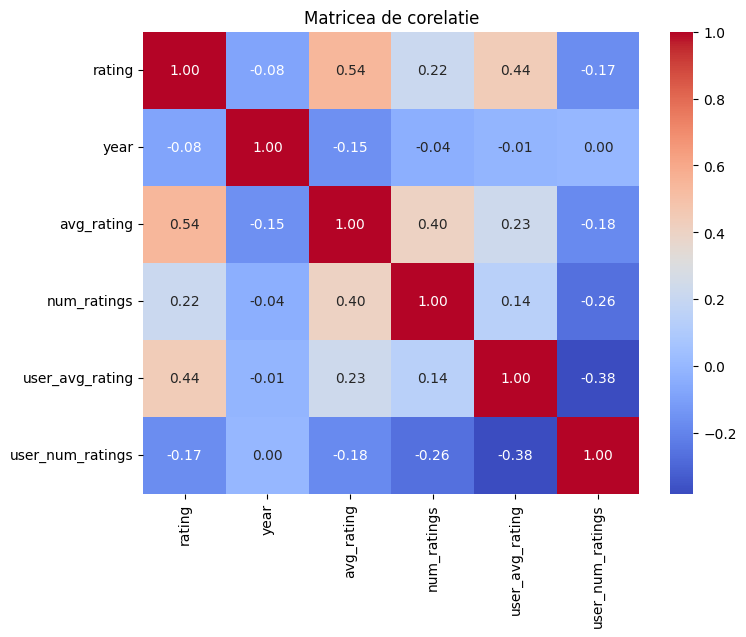

In [21]:
import seaborn as sns

numeric_cols = ['rating', 'year', 'avg_rating', 'num_ratings',
                'user_avg_rating', 'user_num_ratings']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matricea de corelatie')
plt.show()


In [22]:
# sa incerc si altceva inafara de k-nn
# sa incerc si random forest
# xg boost
# gru
# lstm 
# sa incerc cat de multe

Split train/test
Rating-urile vor fi impartite in felul urmator: 80% pentru antrenare si 20% pentru testare.

In [23]:
from sklearn.model_selection import train_test_split

# folosesc doar coloanele necesare pentru modelul colaborativ
ratings_cf = ratings[['userId', 'movieId', 'rating']].copy()

train_ratings, test_ratings = train_test_split(
    ratings_cf, test_size=0.2, random_state=42
)

print(f"Train: {train_ratings.shape[0]} rating-uri")
print(f"Test:  {test_ratings.shape[0]} rating-uri")
print(f"Useri unici (train): {train_ratings['userId'].nunique()}")
print(f"Filme unice (train): {train_ratings['movieId'].nunique()}")

Train: 80668 rating-uri
Test:  20168 rating-uri
Useri unici (train): 610
Filme unice (train): 8983


# K-NN - Item-Based

In [24]:
# Matrice user-movie pentru train
user_movie_matrix = train_ratings.pivot_table(
    index='movieId',
    columns='userId',
    values='rating',
    fill_value=0
)
print(f"Dimensiuni matrice: {user_movie_matrix.shape}")
print(f"(filme x useri)")
display(user_movie_matrix.head())

Dimensiuni matrice: (8983, 610)
(filme x useri)


userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,0.0,0.0,4.5,0.0,0.0,0.0,...,0.0,0.0,4.0,3.0,4.0,2.5,0.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# Convertire la matrice sparse pentru eficienta
from scipy.sparse import csr_matrix
matrix_sparse = csr_matrix(user_movie_matrix.values)

In [26]:
from sklearn.neighbors import NearestNeighbors

knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10)
knn_model.fit(matrix_sparse)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [27]:
def recommend_similar_movies(movie_id, n=10):
    idx = user_movie_matrix.index.get_loc(movie_id)
    distances, indices = knn_model.kneighbors(matrix_sparse[idx], n_neighbors=n+1)
    similar_ids = user_movie_matrix.index[indices[0][1:]]  # exclud filmul insusi
    return movies[movies['movieId'].isin(similar_ids)][['title', 'genres']]

display(recommend_similar_movies(18))  # Toy Story

,title,genres
2687,Hamlet,Crime|Drama|Romance|Thriller
3690,Rare Birds,Comedy|Drama
3789,Human Nature,Comedy|Romance
3817,Deuces Wild,Drama
3833,"Believer, The",Drama
3859,Gangster No. 1,Action|Crime|Thriller
3976,Ballistic: Ecks vs. Sever,Action|Thriller
3989,Wasabi,Action|Comedy|Crime|Drama|Thriller
4906,Mad Dog and Glory,Comedy|Drama|Romance
7775,We Bought a Zoo,Comedy|Drama


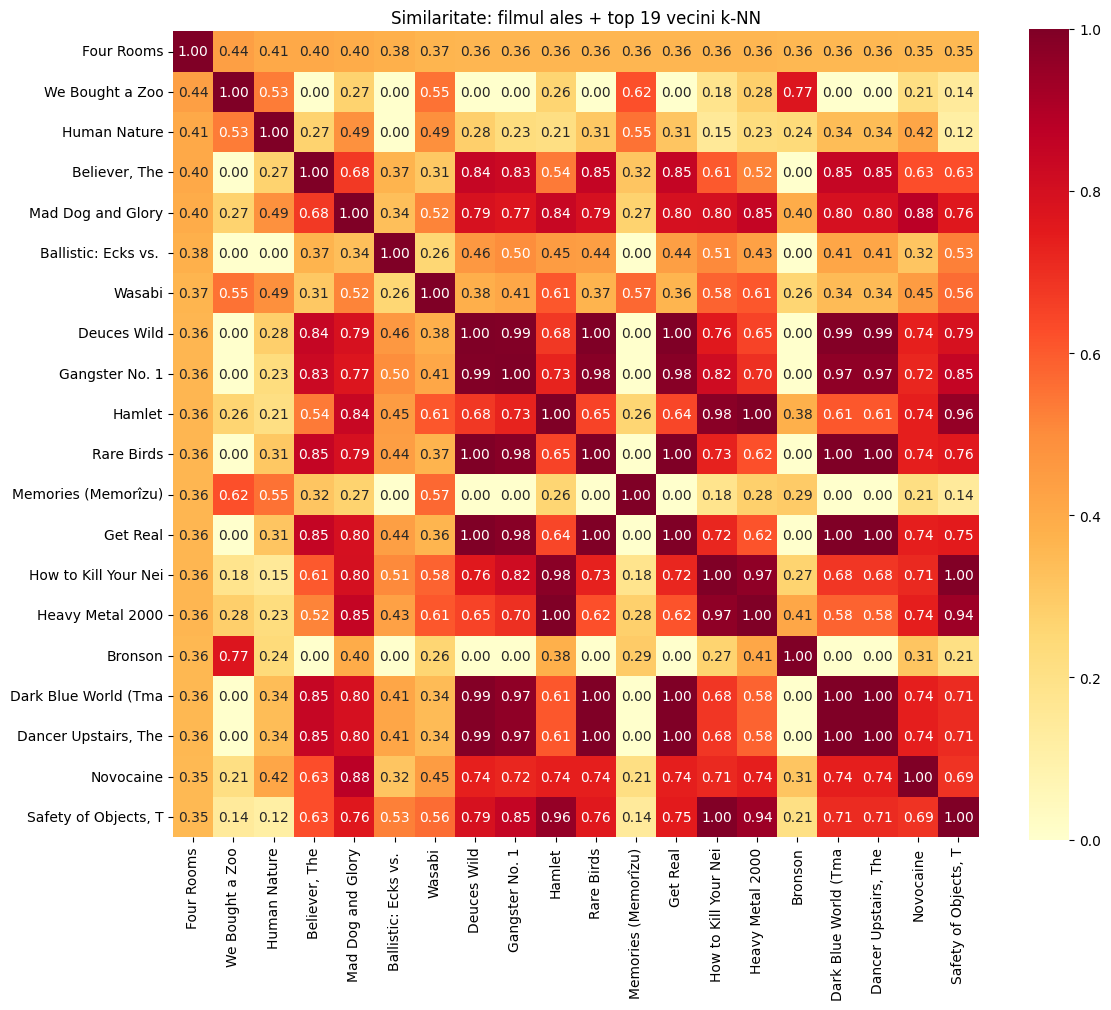

In [28]:
# Film ales + cei mai similari 19 vecini
movie_id = 18
idx = user_movie_matrix.index.get_loc(movie_id)
distances, indices = knn_model.kneighbors(matrix_sparse[idx], n_neighbors=20)

# Lista de movieIds (filmul + vecinii)
selected_ids = user_movie_matrix.index[indices[0]].tolist()

# Calcul imilaritate intre aceste 20 de filme
indices_in_matrix = [user_movie_matrix.index.get_loc(mid) for mid in selected_ids]
subset_matrix = matrix_sparse[indices_in_matrix]

from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(subset_matrix)

titles_short = [movies[movies['movieId']==mid]['title'].values[0][:20] for mid in selected_ids]

plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=titles_short, yticklabels=titles_short, 
            cmap='YlOrRd', annot=True, fmt='.2f', square=True)
plt.title(f'Similaritate: filmul ales + top 19 vecini k-NN')
plt.tight_layout()
plt.show()




# K-NN User-Based

In [29]:
# Matrice user-movie pentru training
user_matrix = train_ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating',
    fill_value=0
)
print(f"Dimensiuni matrice user-based: {user_matrix.shape}")
display(user_matrix.head())

Dimensiuni matrice user-based: (610, 8983)


movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
user_matrix_sparse = csr_matrix(user_matrix.values)

user_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10)
user_knn.fit(user_matrix_sparse)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [31]:
def recommend_user_based(user_id, n=10, k=10):

    idx = user_matrix.index.get_loc(user_id)
    distances, indices = user_knn.kneighbors(user_matrix_sparse[idx], n_neighbors=k+1)
    
    similar_users = user_matrix.index[indices[0][1:]]
    similarities = 1 - distances[0][1:]
    
    # Filme deja vazute => exclus din recomandari
    seen = set(train_ratings[train_ratings['userId'] == user_id]['movieId'])
    
    # Calcul Scor pentru film propus de vecini
    scores = {}
    sim_sum = {}
    for sim_user, sim in zip(similar_users, similarities):
        user_ratings = train_ratings[train_ratings['userId'] == sim_user]
        for _, row in user_ratings.iterrows():
            mid = row['movieId']
            if mid in seen:
                continue
            scores[mid] = scores.get(mid, 0) + sim * row['rating']
            sim_sum[mid] = sim_sum.get(mid, 0) + sim
    
    # Normalizare si sortare
    final = {m: scores[m] / sim_sum[m] for m in scores if sim_sum[m] > 0}
    top = sorted(final.items(), key=lambda x: x[1], reverse=True)[:n]
    top_ids = [m for m, _ in top]
    
    result = movies[movies['movieId'].isin(top_ids)][['movieId', 'title', 'genres']].copy()
    result['score'] = result['movieId'].map(dict(top))
    return result.sort_values('score', ascending=False)

display(recommend_user_based(user_id=1, n=10))


,movieId,title,genres,score
449,514,"Ref, The",Comedy,5.0
981,1282,Fantasia,Animation|Children|Fantasy|Musical,5.0
1568,2106,Swing Kids,Drama|War,5.0
1711,2300,"Producers, The",Comedy,5.0
2022,2694,Big Daddy,Comedy,5.0
2030,2702,Summer of Sam,Drama,5.0
2308,3060,"Commitments, The",Comedy|Drama|Musical,5.0
2452,3265,Hard-Boiled (Lat sau san taam),Action|Crime|Drama|Thriller,5.0
2779,3717,Gone in 60 Seconds,Action|Crime,5.0
6497,53322,Ocean's Thirteen,Crime|Thriller,5.0


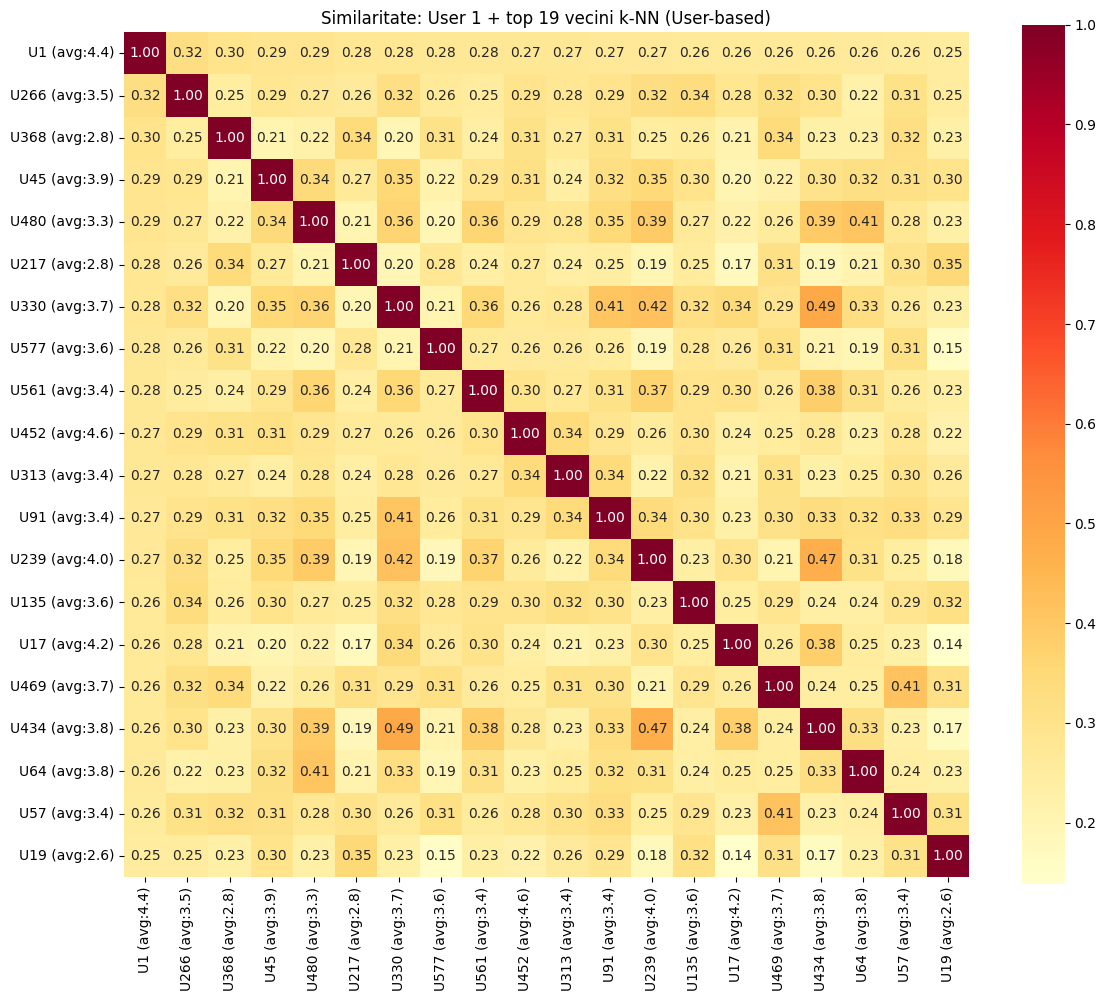

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

# User ales + top 19 vecini similari
user_id = 1
idx = user_matrix.index.get_loc(user_id)
distances, indices = user_knn.kneighbors(user_matrix_sparse[idx], n_neighbors=20)

# Lista userIds (userul + vecinii)
selected_user_ids = user_matrix.index[indices[0]].tolist()

# Calcul matrice similaritate
indices_in_matrix = [user_matrix.index.get_loc(uid) for uid in selected_user_ids]
subset_matrix = user_matrix_sparse[indices_in_matrix]

sim_matrix = cosine_similarity(subset_matrix)

labels = []
for uid in selected_user_ids:
    avg = user_stats[user_stats['userId'] == uid]['user_avg_rating'].values[0]
    labels.append(f"U{uid} (avg:{avg:.1f})")

plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=labels, yticklabels=labels,
            cmap='YlOrRd', annot=True, fmt='.2f', square=True)
plt.title(f'Similaritate: User {user_id} + top 19 vecini k-NN (User-based)')
plt.tight_layout()
plt.show()


# K-NN Content-Based + TF-IDF

Agregarea tag-urilor per film : fiecare film devine un "document"


In [33]:
movie_tags = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
movie_tags.columns = ['movieId', 'tags_text']

print(f"Filme cu tag-uri: {movie_tags.shape[0]} / {movies.shape[0]}")
print(f"Numar mediu de tag-uri per film: {tags.groupby('movieId').size().mean():.1f}")
print(f"Numar maxim de tag-uri per film:  {tags.groupby('movieId').size().max()}")
display(movie_tags.head())

Filme cu tag-uri: 1572 / 9742
Numar mediu de tag-uri per film: 2.3
Numar maxim de tag-uri per film:  181


,movieId,tags_text
0,1,pixar pixar fun
1,2,fantasy magic board game robin williams game
2,3,moldy old
3,5,pregnancy remake
4,7,remake


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF: tag-urile rare si specifice primesc greutate mare
tfidf = TfidfVectorizer(min_df=2, max_df=0.8)
tfidf_matrix = tfidf.fit_transform(movie_tags['tags_text'])

print(f"Matrice TF-IDF: {tfidf_matrix.shape}  (filme x tag-uri unice)")
print(f"Vocabular: {len(tfidf.get_feature_names_out())} termeni unici")
print(f"Densitate: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.2f}% celule non-zero")

# Exemplu concret: vedem top tag-uri pentru primul film din movie_tags
sample_idx = 0
sample_movie_id = movie_tags.iloc[sample_idx]['movieId']
sample_title = movies[movies['movieId'] == sample_movie_id]['title'].values[0]

vocab = tfidf.get_feature_names_out()
row = tfidf_matrix[sample_idx].toarray().flatten()
top_terms_idx = row.argsort()[::-1][:10]

print(f"\nTop 10 tag-uri pentru '{sample_title}' (movieId={sample_movie_id}):")
for i in top_terms_idx:
    if row[i] > 0:
        print(f"  {vocab[i]:<30} TF-IDF = {row[i]:.3f}")


Matrice TF-IDF: (1572, 765)  (filme x tag-uri unice)
Vocabular: 765 termeni unici
Densitate: 0.36% celule non-zero

Top 10 tag-uri pentru 'Toy Story' (movieId=1):
  pixar                          TF-IDF = 0.903
  fun                            TF-IDF = 0.429


In [35]:
# Content-based k-NN: cosine similarity pe vectorii TF-IDF
content_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10)
content_knn.fit(tfidf_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [36]:
def recommend_by_tags(movie_id, n=10):
    """Recomanda top N filme similare pe baza tag-urilor (content-based k-NN)."""
    if movie_id not in movie_tags['movieId'].values:
        print(f"Filmul {movie_id} nu are tag-uri in dataset")
        return None
    
    idx = movie_tags.index[movie_tags['movieId'] == movie_id][0]
    distances, indices = content_knn.kneighbors(tfidf_matrix[idx], n_neighbors=n + 1)
    
    # Exclud filmul insusi (primul vecin, distanta 0)
    similar_ids = movie_tags.iloc[indices[0][1:]]['movieId'].values
    similarities = 1 - distances[0][1:]
    
    result = movies[movies['movieId'].isin(similar_ids)][['movieId', 'title', 'genres']].copy()
    result['similarity'] = result['movieId'].map(dict(zip(similar_ids, similarities)))
    return result.sort_values('similarity', ascending=False)


# Top filme dupa numar de tag-uri (candidati buni pentru test)
top_tagged = tags.groupby('movieId').size().nlargest(10)
print("Filme cu cele mai multe tag-uri:")
for mid, cnt in top_tagged.items():
    title = movies[movies['movieId'] == mid]['title'].values[0]
    print(f"  movieId={mid:>6}  ({cnt} tag-uri): {title}")

# Test: alegem filmul cu cele mai multe tag-uri
test_movie_id = top_tagged.index[0]
test_title = movies[movies['movieId'] == test_movie_id]['title'].values[0]

print(f"\nRecomandari content-based pentru '{test_title}' (movieId={test_movie_id}):")
display(recommend_by_tags(test_movie_id, n=10))


Filme cu cele mai multe tag-uri:
  movieId=   296  (181 tag-uri): Pulp Fiction
  movieId=  2959  (54 tag-uri): Fight Club
  movieId=   924  (41 tag-uri): 2001: A Space Odyssey
  movieId=   293  (35 tag-uri): Léon: The Professional (a.k.a. The Professional) (Léon)
  movieId=  7361  (34 tag-uri): Eternal Sunshine of the Spotless Mind
  movieId=  1732  (32 tag-uri): Big Lebowski, The
  movieId=  4878  (29 tag-uri): Donnie Darko
  movieId=   260  (26 tag-uri): Star Wars: Episode IV - A New Hope
  movieId= 79132  (26 tag-uri): Inception
  movieId=135536  (19 tag-uri): Suicide Squad

Recomandari content-based pentru 'Pulp Fiction' (movieId=296):


,movieId,title,genres,similarity
1298,1732,"Big Lebowski, The",Comedy|Crime,0.405706
828,1089,Reservoir Dogs,Crime|Mystery|Thriller,0.369060
4584,6810,Sleeping with the Enemy,Drama|Thriller,0.308847
2226,2959,Fight Club,Action|Crime|Drama|Thriller,0.289201
8063,99114,Django Unchained,Action|Drama|Western,0.287167
6016,38061,Kiss Kiss Bang Bang,Comedy|Crime|Mystery|Thriller,0.254842
8757,128360,The Hateful Eight,Western,0.246594
4176,6016,City of God (Cidade de Deus),Action|Adventure|Crime|Drama|Thriller,0.230637
254,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller,0.217936
905,1203,12 Angry Men,Drama,0.198506


In [37]:
# Afisare tokeni pentru filmul sursa + filmele recomandate
recs = recommend_by_tags(test_movie_id, n=10)
recs_with_tags = recs.merge(movie_tags, on='movieId', how='left')

source_tags_text = movie_tags[movie_tags['movieId'] == test_movie_id]['tags_text'].values[0]
source_tokens = sorted(set(source_tags_text.split()))

print(f"Film sursa: '{test_title}' (movieId={test_movie_id})")
print(f"Tokeni ({len(source_tokens)}): {', '.join(source_tokens)}\n")
print(f"{'='*80}\n")

for _, row in recs_with_tags.sort_values('similarity', ascending=False).iterrows():
    tokens = sorted(set(row['tags_text'].split()))
    shared = set(source_tokens) & set(tokens)
    print(f"[similarity={row['similarity']:.3f}]  {row['title']}")
    print(f"  Tokeni ({len(tokens)}): {', '.join(tokens)}")
    print(f"  Tokeni comuni ({len(shared)}): {', '.join(shared)}\n")



Film sursa: 'Pulp Fiction' (movieId=296)
Tokeni (199): &, 1990s, 250, achronological, acting, action, actors, aggressive, amazing, angeles, anthology, ass, assassin, atmospheric, avary, awesome, bad, bad-ass, bible, biblical, big, black, blood, bloody, boys, bruce, brutality, buscemi, cast, casual, character, characters, cheese, classic, coke, comedy, content, conversation, cool, crime, cult, culture, d'or, dance, dancing, dark, development, dialogue, dialogues, different, diner, disjointed, disturbing, drama, drug, drugs, ending, ensemble, entertaining, entirely, episodic, exciting, fast, fast-paced, film, film-noir, foul, fun, funny, gangster, gangsters, genius, golden, good, gore, great, gritty, guns, harvey, heroin, highly, hit, hitman, homosexuality, humor, humour, iconic, images, imdb, including, innovative, intellectual, intelligent, intense, interesting, intertwining, interwoven, ironic, irony, jackson, john, keitel, killer-as-protagonist, l., language, los, mafia, masterpiece,

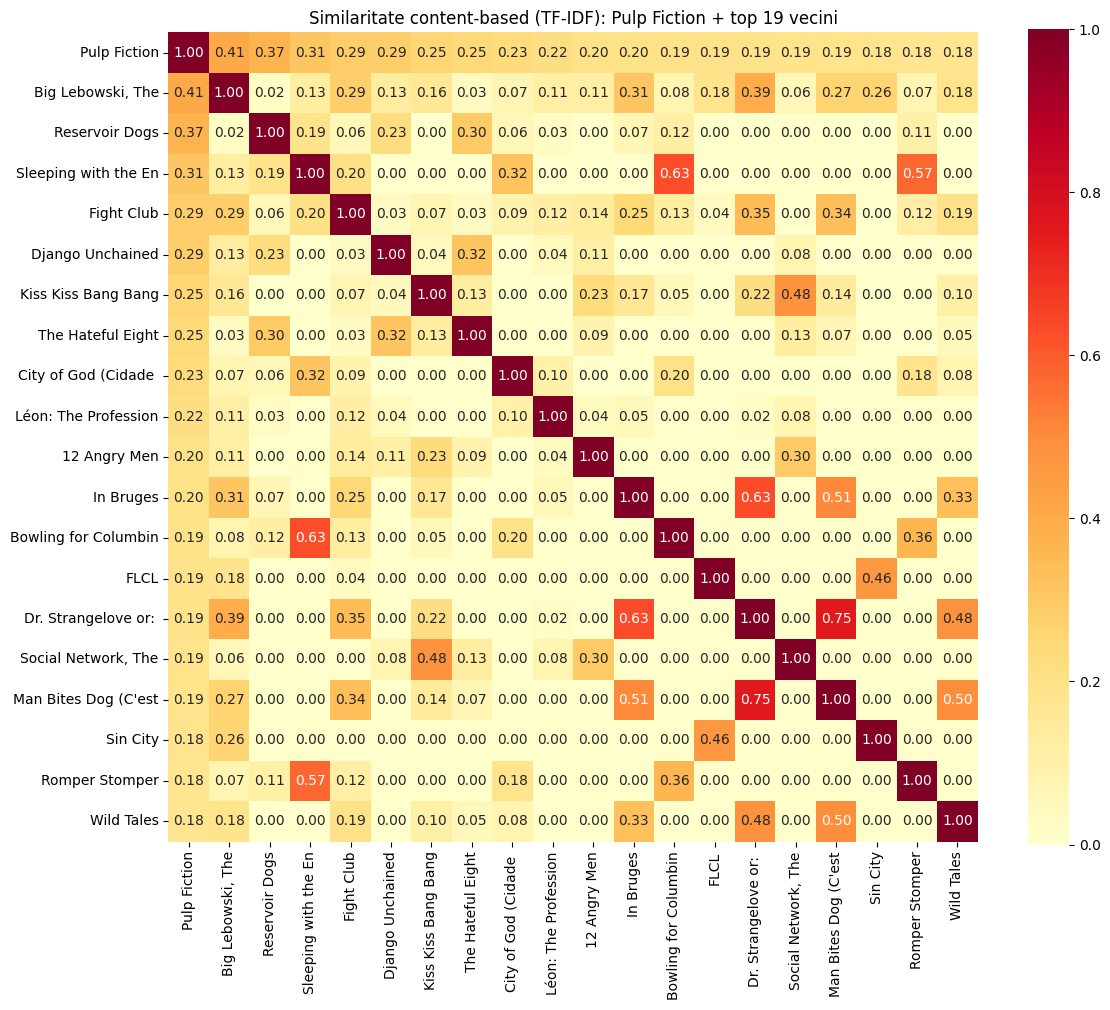

In [38]:
# Heatmap similaritate content-based (TF-IDF): filmul ales + top 19 vecini
test_idx = movie_tags.index[movie_tags['movieId'] == test_movie_id][0]
distances, indices = content_knn.kneighbors(tfidf_matrix[test_idx], n_neighbors=20)

selected_ids = movie_tags.iloc[indices[0]]['movieId'].tolist()
subset_matrix = tfidf_matrix[indices[0]]
sim_matrix = cosine_similarity(subset_matrix)

titles_short = [movies[movies['movieId'] == mid]['title'].values[0][:20] for mid in selected_ids]

plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=titles_short, yticklabels=titles_short,
            cmap='YlOrRd', annot=True, fmt='.2f', square=True)
plt.title(f'Similaritate content-based (TF-IDF): {test_title[:30]} + top 19 vecini')
plt.tight_layout()
plt.show()


In [39]:
# Comparatie side-by-side: k-NN colaborativ item-based vs. content-based TF-IDF
compare_id = test_movie_id
compare_title = movies[movies['movieId'] == compare_id]['title'].values[0]

if compare_id not in user_movie_matrix.index:
    print(f"'{compare_title}' (movieId={compare_id}) nu e in training-ul colaborativ")
else:
    collab_recs = recommend_similar_movies(compare_id, n=10).reset_index(drop=True)
    content_recs = recommend_by_tags(compare_id, n=10)[['title', 'genres']].reset_index(drop=True)
    
    compare_df = pd.DataFrame({
        'Colaborativ (user-item ratings)': collab_recs['title'] + '  [' + collab_recs['genres'] + ']',
        'Content-based (TF-IDF tag-uri)':  content_recs['title'] + '  [' + content_recs['genres'] + ']'
    })
    
    print(f"Top 10 recomandari pentru: '{compare_title}'\n")
    display(compare_df)


Top 10 recomandari pentru: 'Pulp Fiction'



,Colaborativ (user-item ratings),Content-based (TF-IDF tag-uri)
0,Seven (a.k.a. Se7en) [Mystery|Thriller],"Big Lebowski, The [Comedy|Crime]"
1,"Usual Suspects, The [Crime|Mystery|Thriller]",Reservoir Dogs [Crime|Mystery|Thriller]
2,Braveheart [Action|Drama|War],Sleeping with the Enemy [Drama|Thriller]
3,"Shawshank Redemption, The [Crime|Drama]",Fight Club [Action|Crime|Drama|Thriller]
4,Forrest Gump [Comedy|Drama|Romance|War],Django Unchained [Action|Drama|Western]
5,"Silence of the Lambs, The [Crime|Horror|Thril...",Kiss Kiss Bang Bang [Comedy|Crime|Mystery|Thr...
6,Reservoir Dogs [Crime|Mystery|Thriller],The Hateful Eight [Western]
7,"Matrix, The [Action|Sci-Fi|Thriller]",City of God (Cidade de Deus) [Action|Adventur...
8,American Beauty [Drama|Romance],Léon: The Professional (a.k.a. The Professiona...
9,Fight Club [Action|Crime|Drama|Thriller],12 Angry Men [Drama]


# Random Forest

Alegere features care urmeaza sa fie folosite

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Features-uri folosite
features = ['avg_rating', 'num_ratings', 'user_avg_rating', 
            'user_num_ratings', 'year']

X = df[features]
y = df['rating']

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
display(X.head())


Shape X: (100836, 5)
Shape y: (100836,)


,avg_rating,num_ratings,user_avg_rating,user_num_ratings,year
0,3.920930,215.0,4.366379,232,1995.0
1,3.259615,52.0,4.366379,232,1995.0
2,3.946078,102.0,4.366379,232,1995.0
3,3.975369,203.0,4.366379,232,1995.0
4,4.237745,204.0,4.366379,232,1995.0


Train / Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} exemple")
print(f"Test:  {X_test.shape[0]} exemple")


Train: 80668 exemple
Test:  20168 exemple


Antrenare Random Forest


In [42]:
rf_model = RandomForestRegressor(
    n_estimators=100,      # 100 arbori
    max_depth=10,          # adancime arbore
    random_state=42,
    n_jobs=-1              # folosire toate core-uri CPU
)

rf_model.fit(X_train, y_train)
print("Model antrenat")


Model antrenat


In [43]:
# Predictii pe test set
y_pred = rf_model.predict(X_test)

# Metrici
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")


RMSE: 0.7960
MAE:  0.5986


,feature,importance
0,avg_rating,0.608087
2,user_avg_rating,0.309048
3,user_num_ratings,0.032191
1,num_ratings,0.025977
4,year,0.024697


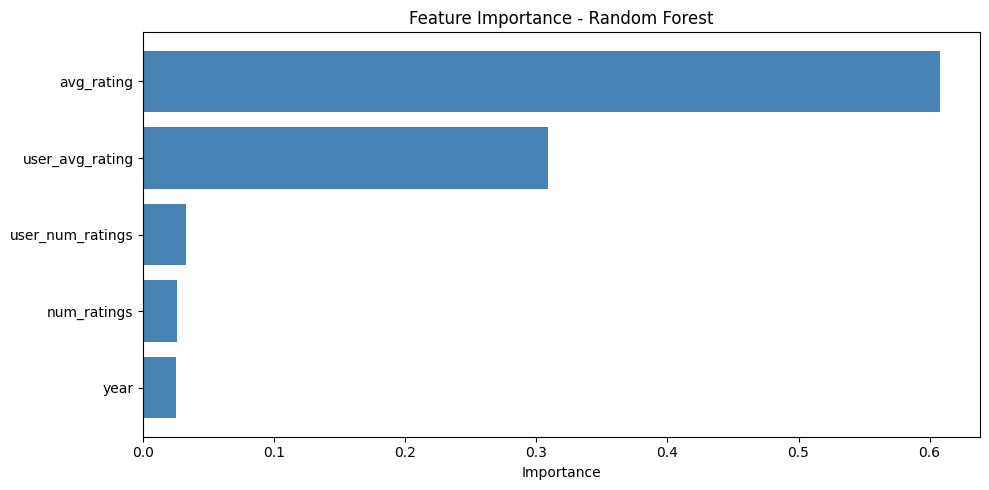

In [44]:
importances = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

display(importances)

# Vizualizare
plt.figure(figsize=(10, 5))
plt.barh(importances['feature'], importances['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



In [45]:
def predict_rating_rf(user_id, movie_id):
    """Prezice rating-ul pe care userul l-ar da filmului."""
    # Preia features-urile userului
    user_info = user_stats[user_stats['userId'] == user_id]
    movie_info = movies[movies['movieId'] == movie_id]
    
    if user_info.empty or movie_info.empty:
        return None
    
    # Construieste vectorul de features
    X_new = pd.DataFrame([{
        'avg_rating': movie_info['avg_rating'].values[0],
        'num_ratings': movie_info['num_ratings'].values[0],
        'user_avg_rating': user_info['user_avg_rating'].values[0],
        'user_num_ratings': user_info['user_num_ratings'].values[0],
        'year': movie_info['year'].values[0]
    }])
    
    return rf_model.predict(X_new)[0]


def recommend_rf(user_id, n=10):
    """Recomanda top N filme pentru un user folosind Random Forest."""
    # Filme pe care userul nu le-a vazut
    seen = set(ratings[ratings['userId'] == user_id]['movieId'])
    candidates = movies[~movies['movieId'].isin(seen)].copy()
    
    # Filtru: doar filme cu features complete
    candidates = candidates.dropna(subset=['avg_rating', 'year'])
    
    user_info = user_stats[user_stats['userId'] == user_id].iloc[0]
    
    # Construieste matricea de predictii
    X_candidates = pd.DataFrame({
        'avg_rating': candidates['avg_rating'].values,
        'num_ratings': candidates['num_ratings'].values,
        'user_avg_rating': user_info['user_avg_rating'],
        'user_num_ratings': user_info['user_num_ratings'],
        'year': candidates['year'].values
    })
    
    # Prezice rating-urile pentru toate
    candidates['predicted_rating'] = rf_model.predict(X_candidates)
    
    # Top N
    return candidates.nlargest(n, 'predicted_rating')[['title', 'genres', 'predicted_rating']]

# Test
display(recommend_rf(user_id=1, n=10))


,title,genres,predicted_rating
2125,On the Ropes,Documentary|Drama,4.918857
2480,Black Tar Heroin: The Dark End of the Street,Documentary,4.918857
2665,Bossa Nova,Comedy|Drama|Romance,4.918857
2838,"Five Senses, The",Drama,4.918857
2880,I'm the One That I Want,Comedy,4.918857
2947,Two Family House,Drama,4.918857
3807,Rain,Drama|Romance,4.918857
3852,Cherish,Comedy|Drama|Thriller,4.918857
3923,Martin Lawrence Live: Runteldat,Comedy|Documentary,4.918857
3936,Satin Rouge,Drama|Musical,4.918857


In [46]:
# Encodare pentru genurile cele mai populare
top_genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Romance', 'Sci-Fi', 'Thriller']
for genre in top_genres:
    df[f'is_{genre}'] = df['genres'].str.contains(genre).astype(int)

# Features temporale
df['rating_year'] = df['timestamp'].dt.year
df['rating_month'] = df['timestamp'].dt.month
df['rating_dayofweek'] = df['timestamp'].dt.dayofweek

# Diferenta intre anul filmului si anul rating-ului
df['years_since_release'] = df['rating_year'] - df['year']

features_extended = features + [f'is_{g}' for g in top_genres] + \
                    ['rating_year', 'rating_month', 'years_since_release']


Modelul XGBoost a fost antrenat!
XGBoost RMSE: 0.7790
XGBoost MAE:  0.5870


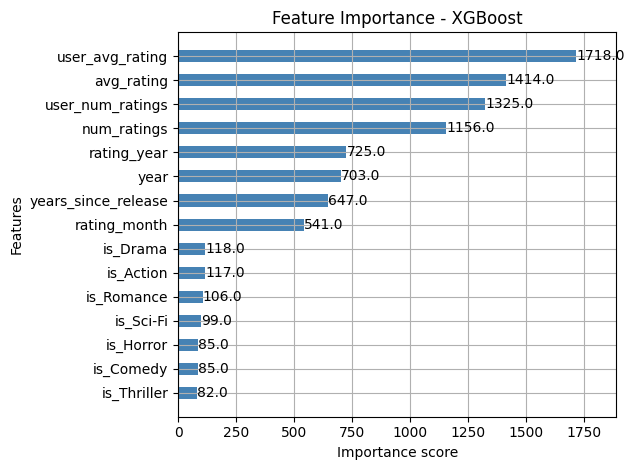

In [47]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Curățăm datele (eliminăm rândurile cu valori lipsă din noile features sau target)
df_xgb = df.dropna(subset=features_extended + ['rating'])
X_ext = df_xgb[features_extended]
y_ext = df_xgb['rating']

# 2. Split în Train / Test folosind features_extended
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_ext, y_ext, test_size=0.2, random_state=42)

# 3. Definim și antrenăm modelul XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_xgb, y_train_xgb)
print("Modelul XGBoost a fost antrenat!")

# 4. Predicții și evaluare (RMSE, MAE)
y_pred_xgb = xgb_model.predict(X_test_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost MAE:  {mae_xgb:.4f}")

# 5. Vizualizăm importanța noilor features
xgb.plot_importance(xgb_model, max_num_features=15, height=0.5, color='steelblue')
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()


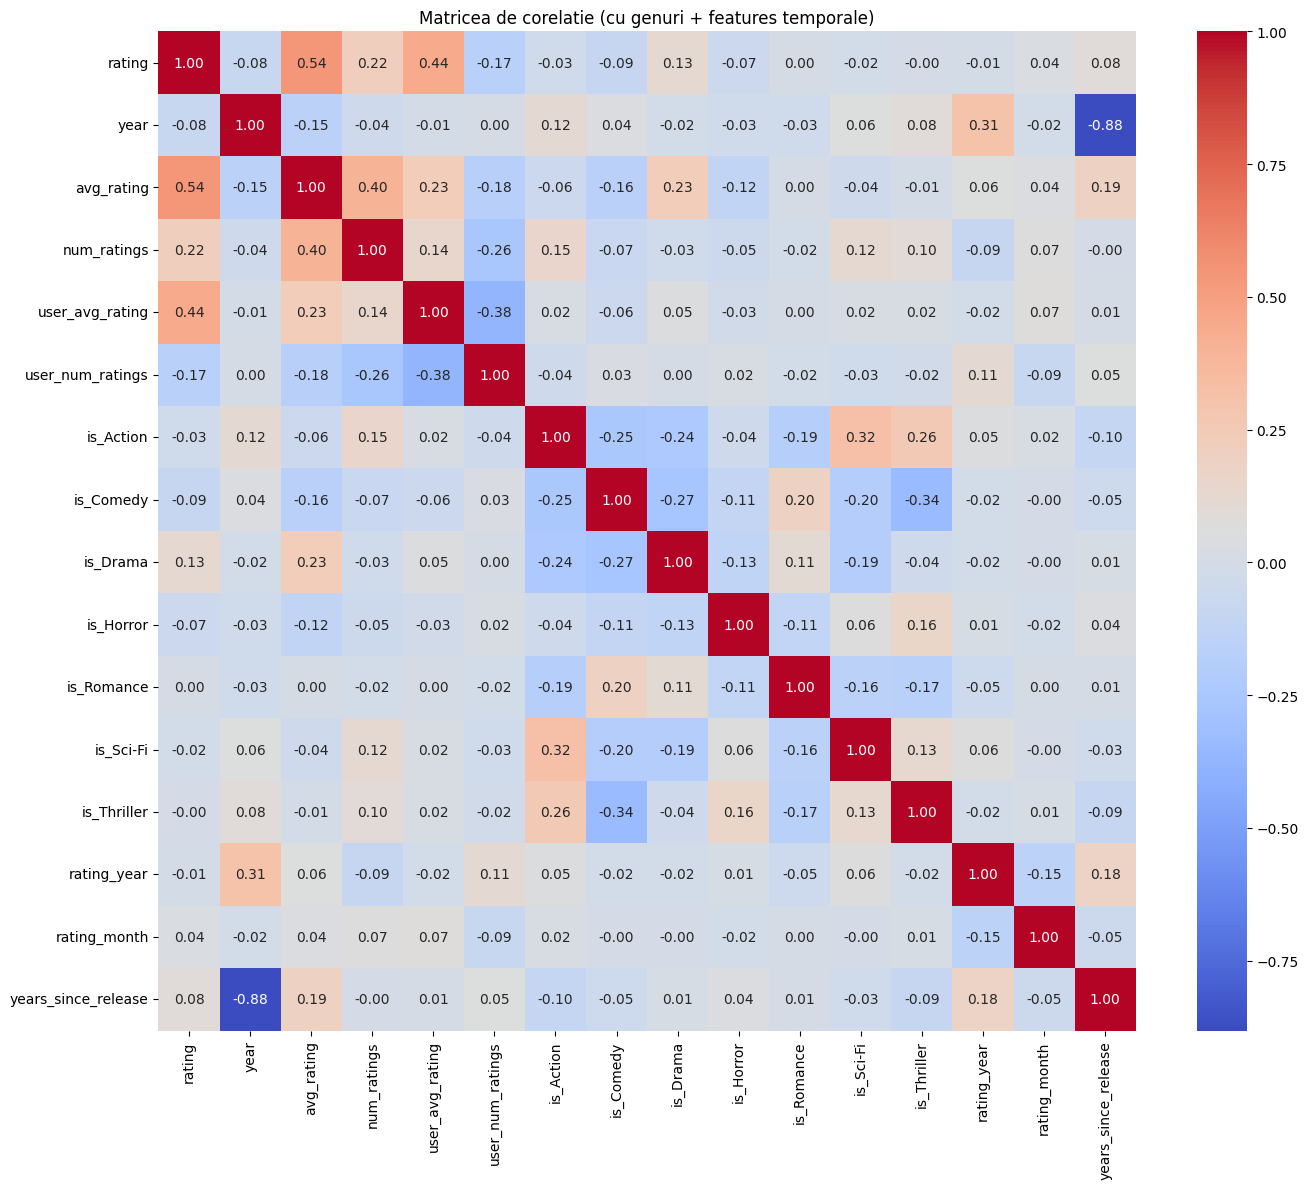

Corelatia genurilor cu rating (individual) si avg_rating (media filmului):


,rating,avg_rating
is_Drama,0.125,0.231
is_Romance,0.002,0.004
is_Thriller,-0.004,-0.008
is_Sci-Fi,-0.020,-0.037
is_Action,-0.034,-0.063
is_Horror,-0.065,-0.120
is_Comedy,-0.089,-0.164


In [48]:
# Matrice de corelatie extinsa (cu genuri + features temporale)
numeric_cols_extended = numeric_cols + [f'is_{g}' for g in top_genres] + \
                        ['rating_year', 'rating_month', 'years_since_release']

plt.figure(figsize=(14, 12))
sns.heatmap(df[numeric_cols_extended].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matricea de corelatie (cu genuri + features temporale)')
plt.tight_layout()
plt.show()

# Focus: corelatia genurilor cu rating-ul individual si cu avg_rating-ul filmului
genre_cols = [f'is_{g}' for g in top_genres]
genre_corr = df[genre_cols + ['rating', 'avg_rating']].corr() \
               .loc[genre_cols, ['rating', 'avg_rating']] \
               .sort_values('avg_rating', ascending=False)

print("Corelatia genurilor cu rating (individual) si avg_rating (media filmului):")
display(genre_corr.round(3))

Baseline (5 features):   RMSE=0.7960  MAE=0.5986
Extended (cu genuri):    RMSE=0.7915  MAE=0.5957
Delta RMSE: +0.0046  (+0.58%)
Delta MAE:  +0.0028  (+0.48%)


,feature,importance
0,avg_rating,0.591769
2,user_avg_rating,0.294148
3,user_num_ratings,0.024689
1,num_ratings,0.020781
14,years_since_release,0.016488
12,rating_year,0.016436
4,year,0.013581
13,rating_month,0.010927
5,is_Action,0.001724
9,is_Romance,0.001713


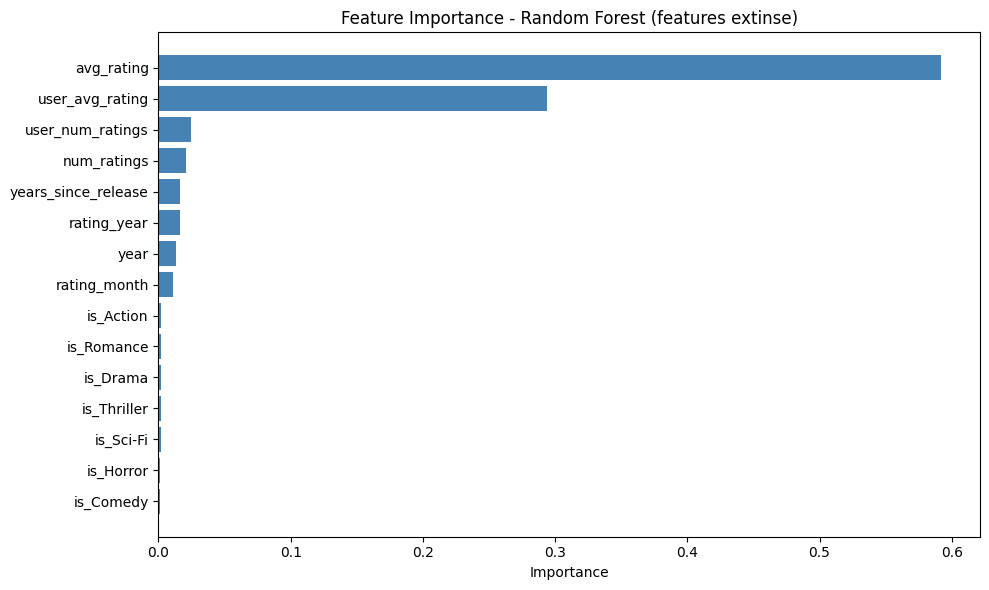

In [49]:
# Comparatie: baseline (5 features) vs features extinse (cu genuri + temporal)
X_ext = df[features_extended]
y_ext = df['rating']

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y_ext, test_size=0.2, random_state=42
)

rf_ext = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_ext.fit(X_train_ext, y_train_ext)

y_pred_ext = rf_ext.predict(X_test_ext)
rmse_ext = np.sqrt(mean_squared_error(y_test_ext, y_pred_ext))
mae_ext = mean_absolute_error(y_test_ext, y_pred_ext)

print(f"Baseline (5 features):   RMSE={rmse:.4f}  MAE={mae:.4f}")
print(f"Extended (cu genuri):    RMSE={rmse_ext:.4f}  MAE={mae_ext:.4f}")
print(f"Delta RMSE: {rmse - rmse_ext:+.4f}  ({(rmse - rmse_ext) / rmse * 100:+.2f}%)")
print(f"Delta MAE:  {mae - mae_ext:+.4f}  ({(mae - mae_ext) / mae * 100:+.2f}%)")

# Importanta features-urilor extinse
importances_ext = pd.DataFrame({
    'feature': features_extended,
    'importance': rf_ext.feature_importances_
}).sort_values('importance', ascending=False)

display(importances_ext)

plt.figure(figsize=(10, 6))
plt.barh(importances_ext['feature'], importances_ext['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (features extinse)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [50]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200],           # scoate 500 (cel mai scump)
#     'max_depth': [10, None],               # doar 2 valori
#     'min_samples_split': [2, 10],          # doar 2 valori
#     'max_features': ['sqrt']               # fixeaza default-ul bun
# }

# grid = GridSearchCV(
#     RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_grid,
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)
# print(f"Cei mai buni parametri: {grid.best_params_}")
# print(f"Cel mai bun RMSE: {np.sqrt(-grid.best_score_):.4f}")


In [51]:
# User-genre affinity: media rating-urilor pe care userul le-a dat filmelor de fiecare gen
ratings_with_genres = ratings.merge(movies[['movieId', 'genres_list']], on='movieId', how='left')

# Explode: fiecare rating x genurile filmului -> linii separate
ratings_exploded = ratings_with_genres.explode('genres_list')
ratings_exploded = ratings_exploded[
    ratings_exploded['genres_list'].notna() & (ratings_exploded['genres_list'] != '')
]

# Filtrez doar genurile populare (cele deja folosite)
ratings_exploded = ratings_exploded[ratings_exploded['genres_list'].isin(top_genres)]

# Pivot: userId x genre -> avg rating
user_genre_affinity = ratings_exploded.groupby(['userId', 'genres_list'])['rating'].mean().unstack()
user_genre_affinity.columns = [f'affinity_{g}' for g in user_genre_affinity.columns]

# Fill missing cu media userului (userii care n-au votat pe un gen)
user_avg_map = user_stats.set_index('userId')['user_avg_rating']
for col in user_genre_affinity.columns:
    user_genre_affinity[col] = user_genre_affinity[col].fillna(user_avg_map)

print(f"Shape user-genre affinity: {user_genre_affinity.shape}  (useri x genuri)")
display(user_genre_affinity.head())

# Merge in df
df = df.merge(user_genre_affinity, left_on='userId', right_index=True, how='left')
print(f"\nShape df dupa merge: {df.shape}")

Shape user-genre affinity: (610, 7)  (useri x genuri)


,affinity_Action,affinity_Comedy,affinity_Drama,affinity_Horror,affinity_Romance,affinity_Sci-Fi,affinity_Thriller
userId,,,,,,,
1,4.322222,4.277108,4.529412,3.470588,4.307692,4.225000,4.145455
2,3.954545,4.000000,3.882353,3.000000,4.500000,3.875000,3.700000
3,3.571429,1.000000,0.750000,4.687500,0.500000,4.200000,4.142857
4,3.320000,3.509615,3.483333,4.250000,3.379310,2.833333,3.552632
5,3.111111,3.466667,3.800000,3.000000,3.090909,2.500000,3.555556



Shape df dupa merge: (100836, 30)


Model                                   RMSE      MAE
-----------------------------------------------------
Baseline (5 features)                 0.7960   0.5986
Extended (cu genuri binare)           0.7915   0.5957
V3 (cu user-genre affinity)           0.7829   0.5905

Delta RMSE fata de baseline:   +0.0132  (+1.65%)
Delta RMSE fata de extended:   +0.0086  (+1.08%)


,feature,importance
0,avg_rating,0.568952
2,user_avg_rating,0.116438
17,affinity_Drama,0.095622
15,affinity_Action,0.077865
1,num_ratings,0.019406
16,affinity_Comedy,0.015127
14,years_since_release,0.013568
20,affinity_Sci-Fi,0.012568
4,year,0.011819
21,affinity_Thriller,0.010970


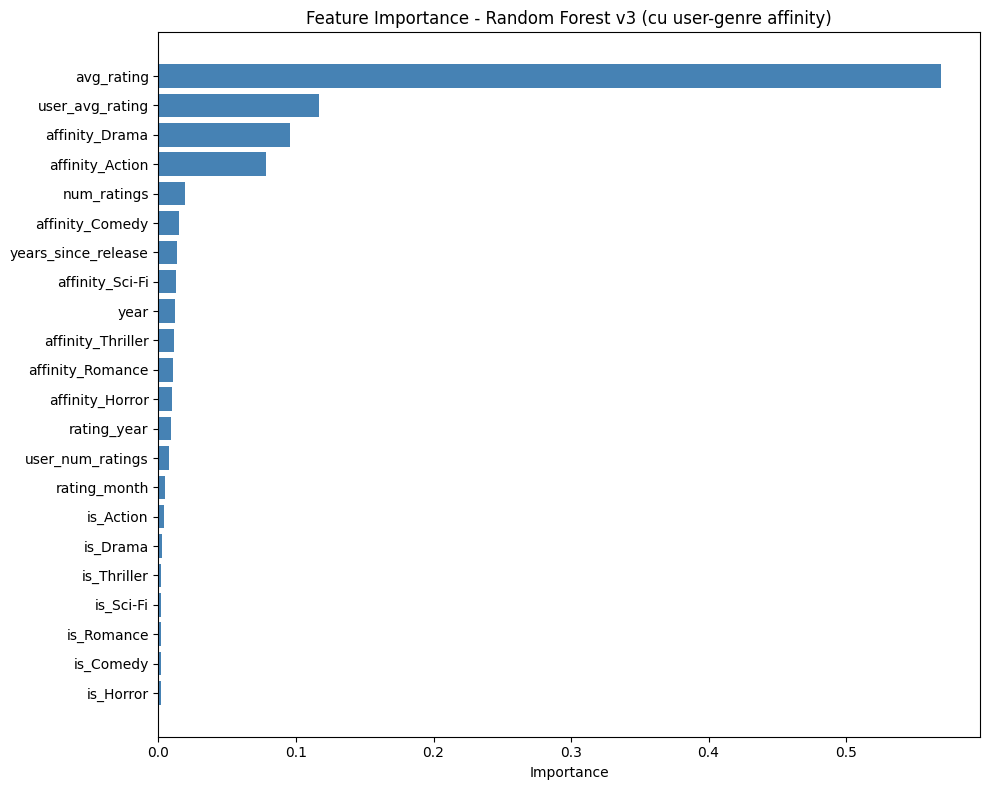

In [52]:
# Features v3: extended + user-genre affinity
affinity_cols = [f'affinity_{g}' for g in top_genres]
features_v3 = features_extended + affinity_cols

X_v3 = df[features_v3]
y_v3 = df['rating']

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.2, random_state=42
)

rf_v3 = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
rf_v3.fit(X_train_v3, y_train_v3)
y_pred_v3 = rf_v3.predict(X_test_v3)

rmse_v3 = np.sqrt(mean_squared_error(y_test_v3, y_pred_v3))
mae_v3 = mean_absolute_error(y_test_v3, y_pred_v3)

print(f"{'Model':<35} {'RMSE':>8} {'MAE':>8}")
print(f"{'-'*53}")
print(f"{'Baseline (5 features)':<35} {rmse:>8.4f} {mae:>8.4f}")
print(f"{'Extended (cu genuri binare)':<35} {rmse_ext:>8.4f} {mae_ext:>8.4f}")
print(f"{'V3 (cu user-genre affinity)':<35} {rmse_v3:>8.4f} {mae_v3:>8.4f}")
print(f"\nDelta RMSE fata de baseline:   {rmse - rmse_v3:+.4f}  ({(rmse - rmse_v3) / rmse * 100:+.2f}%)")
print(f"Delta RMSE fata de extended:   {rmse_ext - rmse_v3:+.4f}  ({(rmse_ext - rmse_v3) / rmse_ext * 100:+.2f}%)")

# Feature importance
importances_v3 = pd.DataFrame({
    'feature': features_v3,
    'importance': rf_v3.feature_importances_
}).sort_values('importance', ascending=False)

display(importances_v3)

plt.figure(figsize=(10, 8))
plt.barh(importances_v3['feature'], importances_v3['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest v3 (cu user-genre affinity)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [53]:
features_v4 = [c for c in features_v3 if not c.startswith('is_')]
print(f"Features v4 ({len(features_v4)}): {features_v4}")

X_v4 = df[features_v4]
X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, df['rating'], test_size=0.2, random_state=42
)

rf_v4 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_v4.fit(X_train_v4, y_train_v4)
y_pred_v4 = rf_v4.predict(X_test_v4)

rmse_v4 = np.sqrt(mean_squared_error(y_test_v4, y_pred_v4))
mae_v4 = mean_absolute_error(y_test_v4, y_pred_v4)

print(f"\n{'Model':<40} {'RMSE':>8} {'MAE':>8}")
print(f"{'-'*58}")
print(f"{'V3 (cu is_<gen> + affinity)':<40} {rmse_v3:>8.4f} {mae_v3:>8.4f}")
print(f"{'V4 (doar affinity, fara is_<gen>)':<40} {rmse_v4:>8.4f} {mae_v4:>8.4f}")


Features v4 (15): ['avg_rating', 'num_ratings', 'user_avg_rating', 'user_num_ratings', 'year', 'rating_year', 'rating_month', 'years_since_release', 'affinity_Action', 'affinity_Comedy', 'affinity_Drama', 'affinity_Horror', 'affinity_Romance', 'affinity_Sci-Fi', 'affinity_Thriller']

Model                                        RMSE      MAE
----------------------------------------------------------
V3 (cu is_<gen> + affinity)                0.7829   0.5905
V4 (doar affinity, fara is_<gen>)          0.7866   0.5926


In [54]:
def recommend_rf_v3(user_id=1, n=10, min_num_ratings=20):
    """Recomanda top N filme folosind RF v3, filtrand filmele cu putine rating-uri."""
    seen = set(ratings[ratings['userId'] == user_id]['movieId'])
    candidates = movies[~movies['movieId'].isin(seen)].copy()
    candidates = candidates[candidates['num_ratings'] >= min_num_ratings]
    candidates = candidates.dropna(subset=['avg_rating', 'year'])
    
    user_info = user_stats[user_stats['userId'] == user_id].iloc[0]
    user_affinity = user_genre_affinity.loc[user_id] if user_id in user_genre_affinity.index else None
    
    # Construiesc X cu toate features V3
    X = pd.DataFrame({
        'avg_rating': candidates['avg_rating'].values,
        'num_ratings': candidates['num_ratings'].values,
        'user_avg_rating': user_info['user_avg_rating'],
        'user_num_ratings': user_info['user_num_ratings'],
        'year': candidates['year'].values,
        'rating_year': 2018,  # valoare default pentru recomandare
        'rating_month': 7,
        'years_since_release': 2018 - candidates['year'].values,
    })
    for g in top_genres:
        X[f'is_{g}'] = candidates['genres'].str.contains(g).astype(int).values
    for g in top_genres:
        col = f'affinity_{g}'
        X[col] = user_affinity[col] if user_affinity is not None else user_info['user_avg_rating']
    
    X = X[features_v3]  # aliniez ordinea coloanelor cu training-ul
    
    candidates['predicted_rating'] = rf_v3.predict(X)
    
    return candidates.nlargest(n, 'predicted_rating')[
        ['title', 'genres', 'num_ratings', 'avg_rating', 'predicted_rating']
    ]

# Test: compara cu versiunea veche
print("=== VECHI (recommend_rf - baseline, fara filtru): ===")
display(recommend_rf(user_id=1, n=10))

print("\n=== NOU (recommend_rf_v3 + filtru num_ratings >= 20): ===")
display(recommend_rf_v3(user_id=1, n=10, min_num_ratings=20))


=== VECHI (recommend_rf - baseline, fara filtru): ===


,title,genres,predicted_rating
2125,On the Ropes,Documentary|Drama,4.918857
2480,Black Tar Heroin: The Dark End of the Street,Documentary,4.918857
2665,Bossa Nova,Comedy|Drama|Romance,4.918857
2838,"Five Senses, The",Drama,4.918857
2880,I'm the One That I Want,Comedy,4.918857
2947,Two Family House,Drama,4.918857
3807,Rain,Drama|Romance,4.918857
3852,Cherish,Comedy|Drama|Thriller,4.918857
3923,Martin Lawrence Live: Runteldat,Comedy|Documentary,4.918857
3936,Satin Rouge,Drama|Musical,4.918857



=== NOU (recommend_rf_v3 + filtru num_ratings >= 20): ===


,title,genres,num_ratings,avg_rating,predicted_rating
277,"Shawshank Redemption, The",Crime|Drama,317.0,4.429022,4.728216
841,"Streetcar Named Desire, A",Drama,20.0,4.475000,4.712746
659,"Godfather, The",Crime|Drama,192.0,4.289062,4.701613
210,Hoop Dreams,Documentary,29.0,4.293103,4.696215
413,In the Name of the Father,Drama,25.0,4.300000,4.690656
935,Harold and Maude,Comedy|Drama|Romance,26.0,4.288462,4.690563
704,Sunset Blvd. (a.k.a. Sunset Boulevard),Drama|Film-Noir|Romance,27.0,4.333333,4.685683
906,Lawrence of Arabia,Adventure|Drama|War,45.0,4.300000,4.682538
922,"Godfather: Part II, The",Crime|Drama,129.0,4.259690,4.676950
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97.0,4.268041,4.669540


In [56]:
def recommend_xgb(user_id=1, n=10, min_num_ratings=20):
    """Recomanda top N filme folosind modelul XGBoost, filtrand filmele cu putine rating-uri."""
    seen = set(ratings[ratings['userId'] == user_id]['movieId'])
    candidates = movies[~movies['movieId'].isin(seen)].copy()
    candidates = candidates[candidates['num_ratings'] >= min_num_ratings]
    candidates = candidates.dropna(subset=['avg_rating', 'year'])
    
    user_info = user_stats[user_stats['userId'] == user_id].iloc[0]
    
    # Construiesc X cu toate features_extended
    X = pd.DataFrame({
        'avg_rating': candidates['avg_rating'].values,
        'num_ratings': candidates['num_ratings'].values,
        'user_avg_rating': user_info['user_avg_rating'],
        'user_num_ratings': user_info['user_num_ratings'],
        'year': candidates['year'].values,
        'rating_year': 2018,  # valoare default pentru recomandare
        'rating_month': 7,
        'years_since_release': 2018 - candidates['year'].values,
    })
    for g in top_genres:
        X[f'is_{g}'] = candidates['genres'].str.contains(g).astype(int).values
    
    X = X[features_extended]  # aliniez ordinea coloanelor cu training-ul
    
    candidates['predicted_rating'] = xgb_model.predict(X)
    
    return candidates.nlargest(n, 'predicted_rating')[

        ['title', 'genres', 'num_ratings', 'avg_rating', 'predicted_rating']

    ]

# Test
print("\
=== NOU (recommend_xgb + filtru num_ratings >= 20): ===")
display(recommend_xgb(user_id=1, n=10, min_num_ratings=20))


=== NOU (recommend_xgb + filtru num_ratings >= 20): ===


,title,genres,num_ratings,avg_rating,predicted_rating
714,To Catch a Thief,Crime|Mystery|Romance|Thriller,23.0,4.217391,4.715559
690,North by Northwest,Action|Adventure|Mystery|Romance|Thriller,57.0,4.184211,4.707811
686,Rear Window,Mystery|Thriller,84.0,4.261905,4.705646
935,Harold and Maude,Comedy|Drama|Romance,26.0,4.288462,4.693484
841,"Streetcar Named Desire, A",Drama,20.0,4.475000,4.690880
2290,Little Big Man,Western,24.0,4.145833,4.679360
210,Hoop Dreams,Documentary,29.0,4.293103,4.678476
413,In the Name of the Father,Drama,25.0,4.300000,4.670631
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97.0,4.268041,4.667510
277,"Shawshank Redemption, The",Crime|Drama,317.0,4.429022,4.667257
